# ARGUS-FEDER — Getting started with DIII-D disruption data

This notebook introduces the stored **disruption index**: twenty DIII-D shots
run through [disruption-py](https://github.com/MIT-PSFC/disruption-py), the
MIT-PSFC disruption-warning code, with every signal fetched over the Fusion
Data Platform.

Every question below is typed in plain English into a `%%ask` cell. The agent
decides what to look up, writes and runs its own code, and reports back.
**Nothing here requires the reader to write code.**

## What a disruption is

A tokamak plasma is confined by magnetic fields. A **disruption** is a sudden,
uncontrolled loss of that confinement — the plasma current collapses in
milliseconds, dumping its stored energy into the machine wall. On a
research device this is tolerable; on a power plant it would be damaging.
Predicting disruptions early enough to act is one of the field's open problems.

The index holds, for each shot, 63 physics parameters sampled through the
discharge, plus a label saying whether and when that shot disrupted.

## Before you run

The database is not part of the image — place `disruption.sqlite` in
`~/work/_User-Persistent-Storage_CephBlock_/feder/` (survives pod restarts) or
`~/feder_data/`. The setup cell below confirms it is found.

## Setup — what the index contains

Plain Python, no agent. Confirms the file is found and prints its provenance
and coverage.

In [1]:
import os, sys
sys.path.insert(0, os.path.expanduser("~/.deepagents/agent/skills/d3d-disruption"))
from d3d_disruption import index_info, locate_disruption_db

print("database:", locate_disruption_db())
i = index_info()
print(f"{i['n_shots']} shots ({i['n_disrupted']} disrupted), {i['n_sample_rows']:,} sample rows")
print(f"produced by {i['package']} {i['version']} @ {i['commit_sha'][:8]} on {i['produced_at'][:10]}")
print()
print(i['coverage_note'])

database: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/feder/disruption.sqlite
20 shots (10 disrupted), 3,778 sample rows
produced by disruption_py 0.15.0.dev0 @ 9987784e on 2026-08-19

20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.


---
# 1. What is in here

## Where does this data come from, and what does it cover?

*orientation · **answerable***

In [2]:
%%ask --review
What disruption data is available for DIII-D? Tell me where it came from,
which code produced it and at what version, how many shots it covers, and how
many of those disrupted.

I'll consult the d3d-disruption skill, which is exactly for this question.



The skill is clear. No Learnings.md exists for this skill yet, so I'll proceed. Let me write a script to query the disruption index.



Running the overview script to pull provenance, coverage, and disruption counts.



The query succeeded. Let me pull a couple more details — usable parameter count and the method groups — to round out the answer.



Running the parameter-detail script to confirm usable counts and method groups.



All queries succeeded. Here is the complete picture of the DIII-D disruption data available through the d3d-disruption index.

## DIII-D disruption data — overview

**What it is** : a stored, queryable index of disruption-py output for DIII-D, built from a single NetCDF file (`d3d_disruption_example.nc`) that was ingested into a local SQLite database. It carries per-shot disruption labels, disruption timing, and 63 physics parameters sampled as time series through each shot (plasma current, q95, betas, radiated power, n=1 mode amplitude, stored energy, etc.). It is derived time-series data with its own annotation layer — not raw diagnostic waveforms and not the shot catalog.

### Provenance (from the NetCDF global attributes, via `index_info()`)

| Field | Value |
|---|---|
| **Producing code** | `disruption_py` (MIT-PSFC/disruption-py) |
| **Version** | `0.15.0.dev0` |
| **Commit** | `9987784e78ef9736e2fe42142683b3458ff38d8d` |
| **Tokamak** | D3D |
| **Produced by** | `sammuli` on `omega06.gat.com` |
| **Produced at** | 2026-08-19T07:36:50 |
| **Ingested at** | 2026-08-19T18:49:07+00:00 |
| **Source file** | `d3d_disruption_example.nc` |

### Coverage

- **Shots covered** : 20 (shot range 194000–199687)
- **Disrupted** : 10 — shots 194000, 194128, 194292, 194464, 194649, 194968, 195516, 195768, 195985, 196347
- **Not disrupted** : 10 — shots 194005, 194869, 195243, 195805, 196273, 198244, 198643, 199062, 199359, 199687
- **Sample rows** : 3,778 time samples across those shots

**Important caveat on the counts** (the index's own `coverage_note`): this is a **constructed slice, deliberately balanced 10 disrupted / 10 not — not a random sample of DIII-D** . Any rate or fraction computed from it (e.g. 10/20) describes the slice only and says nothing about how often DIII-D disrupts as a whole. The index's `disruption_rate()` function refuses to return a rate for exactly this reason; an archive-wide rate would require the d3drdb disruptions table over a defined shot population.

### Parameters

- **63 parameters** total, in **14 method groups** (e.g. `get_efit_parameters` ×14, `get_ip_parameters` ×5, `get_rt_efit_parameters` ×5, `get_n1_bradial_parameters`/`get_n1rms_parameters` ×4, `get_peaking_factors` ×4, `get_power_parameters` ×4, `get_shape_parameters`/`get_kappa_area` ×4, plus density, ohmic, z, and label/phase groups).
- **60 usable** ; **3 flagged unusable** by the code because they return wrong numbers (upstream disruption-py defects, documented by the dataset authors): `time_domain` (constant 1.0 for every row), `ip_error` (numerically identical to `ip`), and `dipprog_dt` (MA/s vs A/s unit mismatch — use `dipprog_dt_rt` instead).
- Units: 37 explicit unit strings, 26 dimensionless (`'1'`), 0 unknown.

### Disruption labels

- The authoritative label is `time_until_disrupt`, taken from the **human-curated `disruptions` table in d3drdb** .
- disruption-py's own derived estimate, `current_quench_time` (from the Ip decay), **disagrees on 3 of the 20 shots** — 198244, 198643, 199062 — all of which the curated label marks as *not* disrupted. The index uses the curated label, so the class balance stays 10/20.

### What this index can and cannot answer

It answers which shots disrupted and when, the pre-disruption plasma state, and what each parameter means and its units. It does **not** provide raw waveforms (use the shot-fetcher/filterscope skills), per-shot summary scalars or MDSplus tag meanings (use d3d-relational-db), or ELM times (use d3d-elm-index). A shot absent from the index is not evidence it did not disrupt — it simply was not run through disruption-py here.

No files were generated for this answer (it is a data-overview query, not a spatial or chart task), and no image files were read.

## Which shots disrupted, and when?

*labels · **answerable***

In [3]:
%%ask --review
List the shots in the disruption index. For each one, say whether it
disrupted and at what time, and show me the range of disruption times across
the disrupted shots.

I'll consult the d3d-disruption skill to get the exact query patterns for shot lists and disruption times.



The skill is clear. Let me check the helper module's return shapes before writing the query script.



The skill and helper are clear. Writing the script to list all shots with disruption status/timing and compute the disruption-time range.



Running the script to list shots and disruption times.



All 20 shots in the index are listed below with their disruption status and timing.

## Shots in the disruption index

The index covers **20 shots** (194000–199687), **10 disrupted / 10 not** — a constructed, deliberately balanced slice, not a random sample of DIII-D.

| Shot | Disrupted | Disruption time (s) |
|---|---|---|
| 194000 | yes | 0.8296 |
| 194005 | no | — |
| 194128 | yes | 5.6267 |
| 194292 | yes | 4.3318 |
| 194464 | yes | 3.1843 |
| 194649 | yes | 3.3521 |
| 194869 | no | — |
| 194968 | yes | 1.1206 |
| 195243 | no | — |
| 195516 | yes | 1.2182 |
| 195768 | yes | 5.2969 |
| 195805 | no | — |
| 195985 | yes | 4.8000 |
| 196273 | no | — |
| 196347 | yes | 5.4763 |
| 198244 | no | — |
| 198643 | no | — |
| 199062 | no | — |
| 199359 | no | — |
| 199687 | no | — |

### Range of disruption times (10 disrupted shots)

- **Earliest** : 0.8296 s (shot 194000)
- **Latest** : 5.6267 s (shot 194128)
- **Range** : 0.8296 – 5.6267 s (span ≈ 4.80 s)

All disruption times come from `time_until_disrupt`, the human-curated d3drdb disruptions table — the authoritative label. The 10 non-disrupted shots have no disruption time (NULL). No image files were read; this is a data listing only.

---
# 2. Understanding the measurements

## What do these parameters actually mean?

*semantics · **answerable***

The source files carry no units and no descriptions — that information lives in
the index's own parameter dictionary.

In [4]:
%%ask --review
What physics parameters does the disruption index record? Group them by
what produces them, and for a few of the important ones — plasma current, q95,
stored energy, normalised beta — tell me what each means and what units it is
in.

Reading the d3d-disruption skill to get the exact API for listing parameters by method group.



The skill documents the API. Now I'll write a script to list all parameters grouped by producing method and pull the meaning/units for the four key ones.



Running the script to enumerate the parameter groups and key parameter meanings.



The parameter is named `beta_n`, not `betan`. Fixing that and re-running just the key-parameter lookup.



Re-running the script with the corrected parameter name.



All 63 parameters are enumerated below, grouped by the disruption-py method that produced each column, with the four key parameters explained.

## Physics parameters in the disruption index

The index records **63 parameters** (60 usable, 3 flagged unusable), each produced by a disruption-py method. The 14 groups below are the producing methods. Units: `'1'` means dimensionless; `'instrument'` and `'0 / 1'` are categorical/flag values.

### Labels and shot phase (3)
`current_quench_time` (s), `time_until_disrupt` (s), `time_domain` (category — **unusable** )

### `get_btor` / `get_h_alpha` / `get_h98` / `get_zeff_parameters` / `get_power_supply_railed` (5)
`btor` (T), `h98` (1), `h_alpha` (instrument), `power_supply_railed` (0/1), `z_eff` (1)

### `get_density_parameters` (3)
`dn_dt` (m⁻³ s⁻¹), `greenwald_fraction` (1), `n_e` (m⁻³)

### `get_efit_parameters` — equilibrium reconstruction (14)
`beta_n`, `beta_p`, `chisq`, `dbetap_dt` (s⁻¹), `dli_dt` (s⁻¹), `dwmhd_dt` (W), `kappa`, `li`, `lower_gap` (m), `q0`, `q95`, `qstar`, `upper_gap` (m), `wmhd` (J)

### `get_ip_parameters` — plasma current (5)
`dip_dt` (A s⁻¹), `dipprog_dt` (MA s⁻¹ — **unusable** ), `ip` (A), `ip_error` (A — **unusable** ), `ip_prog` (MA)

### `get_n1_bradial_parameters` / `get_n1rms_parameters` — n=1 mode (4)
`n1rms` (T), `n1rms_normalized` (1), `n_equal_1_mode` (T), `n_equal_1_normalized` (1)

### `get_ohmic_parameters` (2)
`p_ohm` (W), `v_loop` (V)

### `get_peaking_factors` (4)
`ne_peaking_cva_rt`, `prad_peaking_cva_rt`, `prad_peaking_xdiv_rt`, `te_peaking_cva_rt` (all 1)

### `get_power_parameters` (4)
`p_ech` (W), `p_nbi` (W), `p_rad` (W), `radiated_fraction` (1)

### `get_rt_density_parameters` — real-time (3)
`dn_dt_rt` (m⁻³ s⁻¹), `greenwald_fraction_rt` (1), `n_e_rt` (m⁻³)

### `get_rt_efit_parameters` — real-time (5)
`beta_p_rt`, `chisq_rt`, `li_rt`, `q95_rt` (all 1), `wmhd_rt` (J)

### `get_rt_ip_parameters` — real-time (5)
`dip_dt_rt` (A s⁻¹), `dipprog_dt_rt` (A s⁻¹), `ip_error_rt` (A), `ip_prog_rt` (A), `ip_rt` (A)

### `get_shape_parameters` / `get_kappa_area` (4)
`aminor` (m), `delta` (1), `kappa_area` (1), `squareness` (1)

### `get_z_parameters` (2)
`zcur` (m), `zcur_normalized` (1)

The `_rt` suffix marks real-time (RTEFIT) variants of the same quantities. The three unusable parameters (`time_domain`, `ip_error`, `dipprog_dt`) are upstream disruption-py defects that return plausible-but-wrong numbers; the code blocks them rather than warning.

## The four key parameters

| Parameter | Meaning (from the index) | Units | Produced by |
|---|---|---|---|
| `ip` | Measured plasma current | A (amperes) | `get_ip_parameters` |
| `q95` | Safety factor at 95% flux surface | dimensionless (`'1'`) | `get_efit_parameters` |
| `wmhd` | Stored magnetic energy | J (joules) | `get_efit_parameters` |
| `beta_n` | Normalised beta | `% m T MA⁻¹` | `get_efit_parameters` |

- **`ip`** — the measured plasma current, in amperes. The central confinement quantity; its decay defines the current quench. 100% filled.
- **`q95`** — the safety factor evaluated at the 95% flux surface, dimensionless. Measures field-line pitch / how "twisted" the magnetic field is; low q95 is a classic disruption precursor. 84.6% filled.
- **`wmhd`** — the stored magnetic energy of the plasma, in joules. Its collapse marks the thermal quench. 84.6% filled.
- **`beta_n`** — normalised beta, in `% m T MA⁻¹` (percent · metres · tesla per mega-ampere). Beta normalised to the Troyon scaling (Ip/aB), the standard figure of merit for how much pressure the plasma holds; exceeding the beta limit is a common disruption trigger. 84.6% filled.

All four are usable and carry no caveats. No image files were read; this is a data listing only.

## Are any of the parameters unreliable?

*data quality · **answerable***

In [5]:
%%ask --review
Are there any parameters in this dataset that should not be used, and if
so why? Explain what is wrong with each one in terms a physicist would
recognise.

Let me consult the d3d-disruption skill to recall the exact API for querying parameter caveats.



The skill documents three flagged parameters. Let me query the index to confirm the exact caveats and verify each defect against the data.



Running the verification script against the index.



All three flagged parameters are confirmed, and I verified each defect directly against the data (shot 194128). Here is the full picture.

## Yes — three parameters are flagged unusable

The index records **63 parameters** ; **60 are usable** and **3 are flagged unusable** (`usable=0`). These are upstream disruption-py defects (version `0.15.0.dev0`, commit `9987784e`) documented by the dataset authors and verified against the data. They do not fail loudly — they return *plausible-looking* numbers, which is exactly why the index blocks them: `fetch_samples()` raises `UnusableParameter` rather than warning, so you cannot silently analyse a column that is wrong.

| Parameter | What it claims to be | What is actually wrong |
|---|---|---|
| `time_domain` | Shot phase (1 = ramp-up, 2 = flat-top, 3 = ramp-down) | Constant 1.0 for every row — carries no information |
| `ip_error` | `ip − ip_prog` (the mismatch between measured and programmed plasma current) | Numerically identical to `ip` — the subtraction is a no-op |
| `dipprog_dt` | Time derivative of programmed current, d(ip_prog)/dt | In MA/s while its real-time twin `dipprog_dt_rt` is in A/s — off by ~5×10⁵ |

### 1. `time_domain` — the flat-top test never fires

The column is meant to tag each sample with its discharge phase (ramp-up / flat-top / ramp-down), which is essential for separating current-ramp disruptions from flat-top ones. The code detects flat-top by testing `|ip_prog| >= 100e3` — i.e. "programmed current above 100 kA". But `ip_prog` is stored in **MA** (order 1), not A, so the threshold of 100,000 is never reached and the test never fires. Every row is therefore labelled phase 1 (ramp-up). **Verified** : all 269 samples of shot 194128 return the single value `1.0`. The column is constant and contains zero discriminative information — you cannot use it to classify the phase of any sample.

### 2. `ip_error` — a unit mismatch that makes the subtraction a no-op

`ip_error` is meant to be `ip − ip_prog`, the difference between the measured plasma current and the programmed waveform — a useful quantity for spotting when the plasma fails to follow the requested current. The bug: `ip_prog` is in **MA** but is used **unscaled** in the subtraction, so instead of subtracting ~0.6 MA from ~0.6 MA (giving a small error), it subtracts ~0.6 from ~600,000 A — a change of one part in a million. **Verified** : median `|ip_error − ip|` = 1.19 A against a median `|ip|` of 589 kA, a relative difference of ~2×10⁻⁶. The column is numerically identical to `ip` and adds nothing beyond `ip` itself.

### 3. `dipprog_dt` — wrong units, off by ~5×10⁵

This is the time derivative of the programmed current, d(ip_prog)/dt — the same `ip_prog` unit error as above, propagated into a derivative. It is reported in **MA/s** , while its real-time twin `dipprog_dt_rt` is in **A/s** . **Verified** : median `|dipprog_dt|` = 2.4×10⁻⁴ vs median `|dipprog_dt_rt|` = 119.3, a ratio of ~2×10⁻⁶ (i.e. the two differ by ~5×10⁵). If you used `dipprog_dt` in a model expecting A/s, every value would be five orders of magnitude too small. The correct column is **`dipprog_dt_rt`** (A/s), which is usable.

### Practical consequence

- `fetch_samples(shot)` with no column list returns only the **60 usable** parameters — the three bad ones are excluded automatically.
- Requesting any of the three raises `UnusableParameter`; you must pass `allow_unusable=True` to retrieve them, and that is only appropriate if you intend to demonstrate the defect itself.
- The real-time variants of the affected quantities (`ip_rt`, `ip_prog_rt`, `dipprog_dt_rt`, `ip_error_rt`) are all usable — the `_rt` family does not share these bugs.

No image files were read; this is a data verification only.

---
# 3. Looking at the plasma

## What does a disruption look like in the data?

*single shot · **answerable***

Reading the d3d-disruption skill to fetch the shot samples correctly.



The skill documents `fetch_samples()` with `time_until_disrupt_max` — exactly what I need. I'll use shot 194128 (disruption at 5.6267 s) and plot the last 200 ms.



Running the script to fetch the last 200 ms of shot 194128 and produce the plot.



The final sample at the disruption instant has missing q95/wmhd. I'll filter out None values per series.



Now updating the plot calls to use the cleaned per-series time arrays.



Also updating the summary print to use the cleaned arrays.



Re-running the corrected script.



The plot is saved. Let me pull the detailed trajectory to describe the sequence of events accurately.



The trajectory is clear. Here is the analysis for shot 194128.

## Shot 194128 — last 200 ms before disruption

I chose shot **194128** (disruption at **5.6267 s** , from the curated d3drdb label). The window contains 55 samples; the three panels show plasma current, q95, and stored energy versus time relative to the disruption (0 = disruption instant).


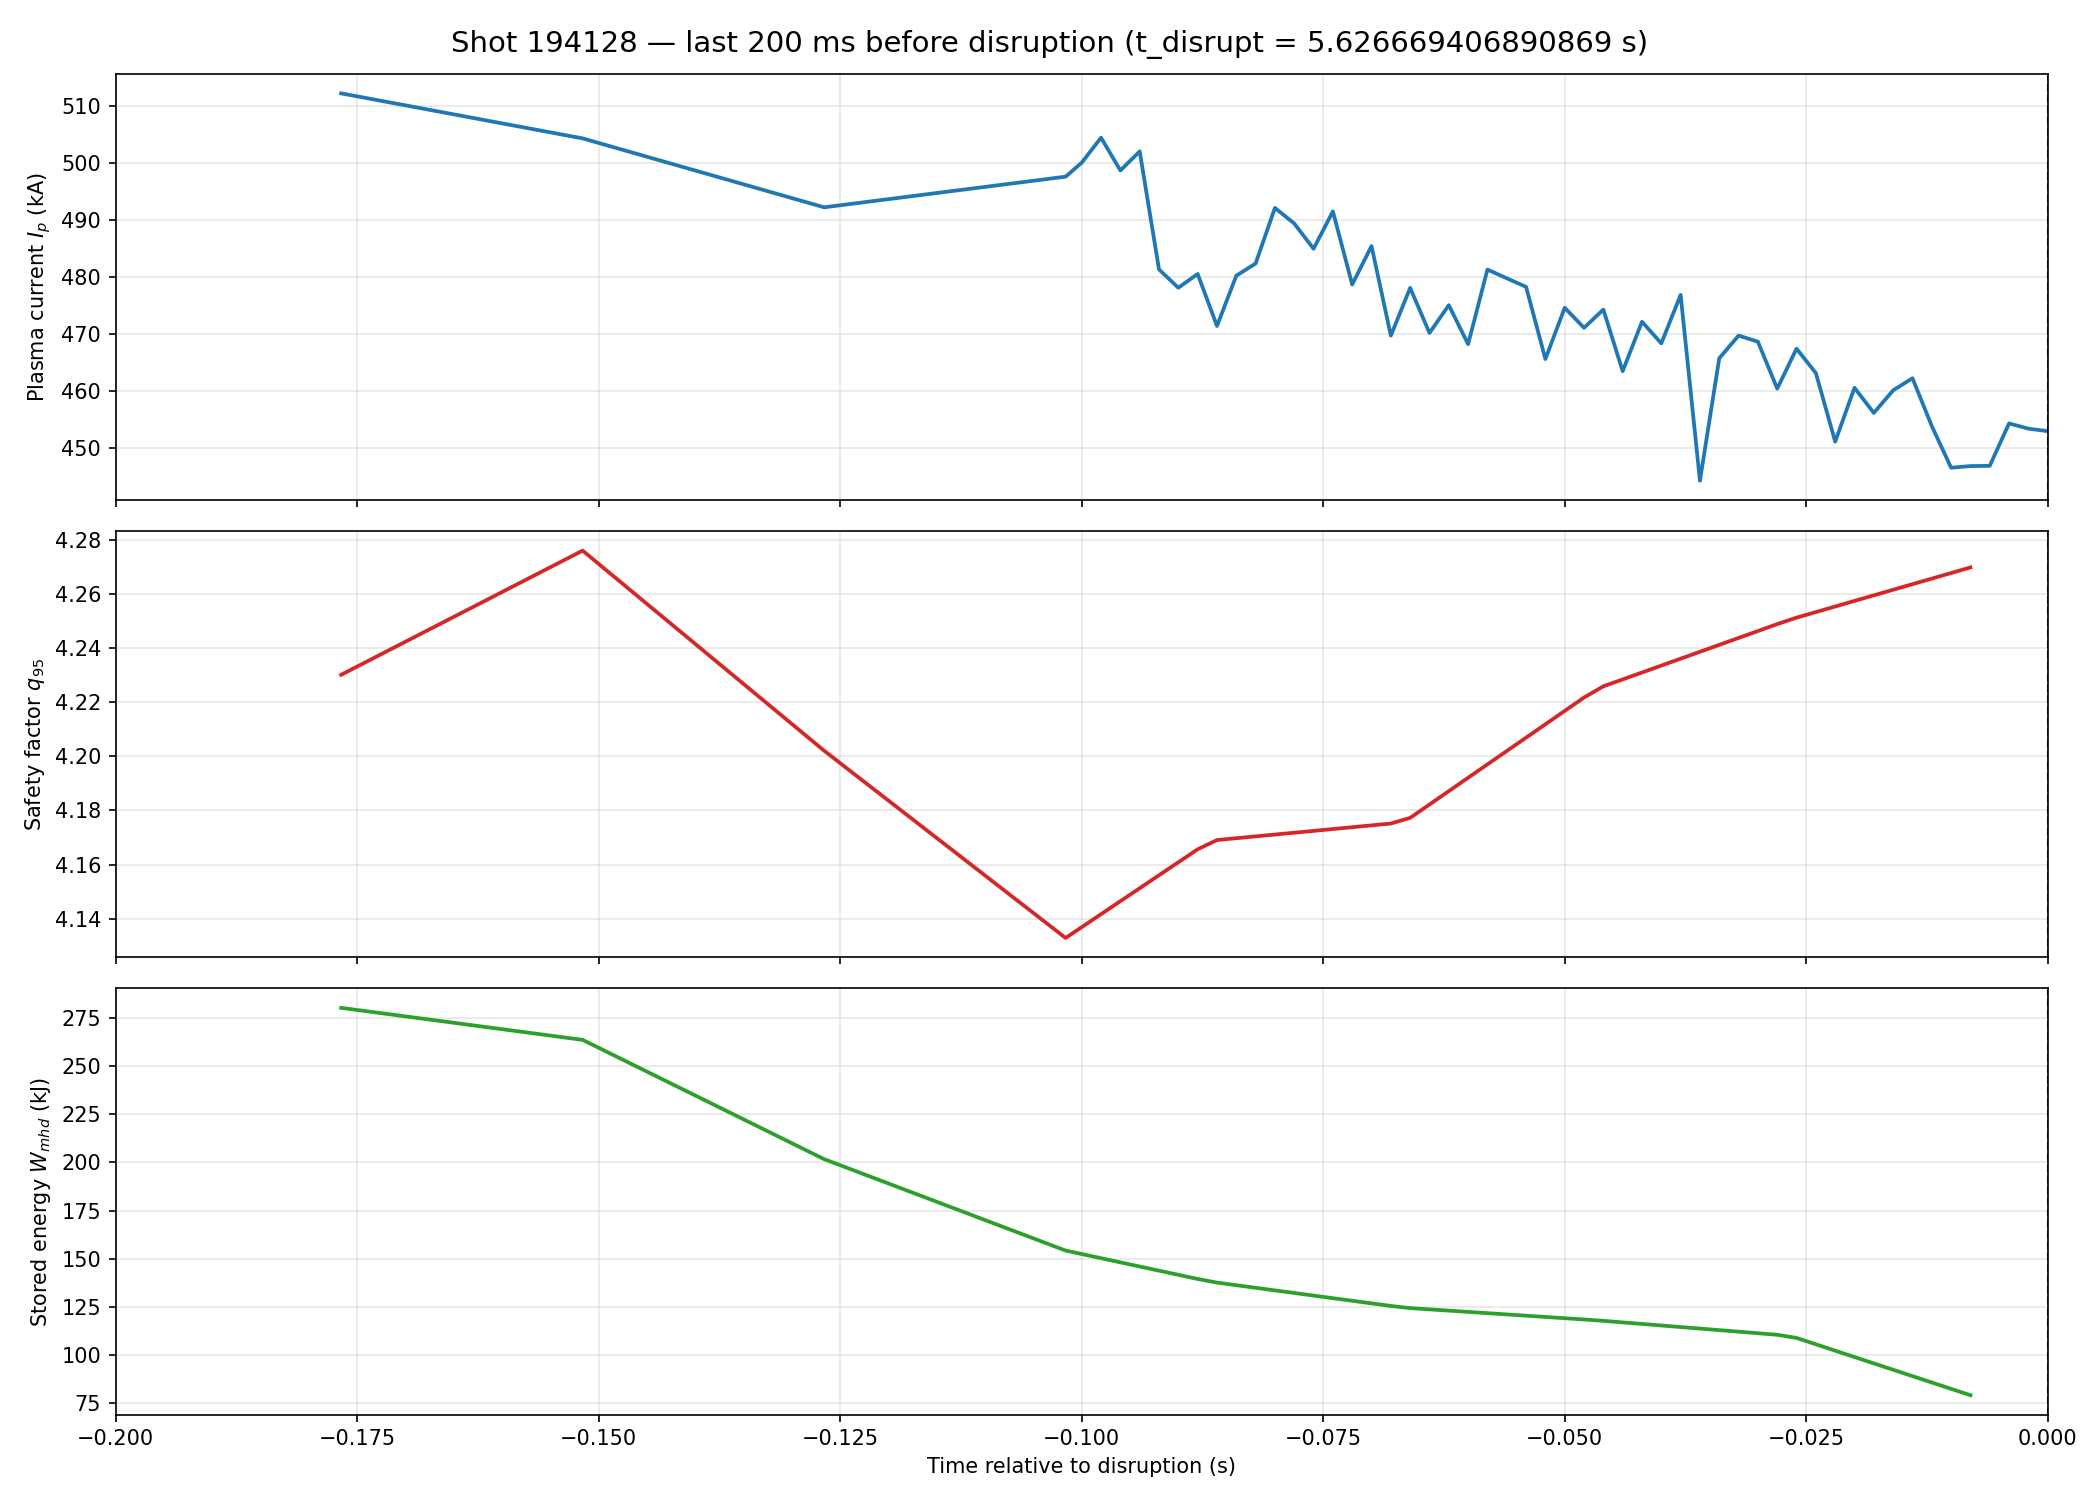

### What happens to each quantity

**Stored energy Wmhd — the dominant feature: a thermal quench.** Wmhd collapses from **280 kJ to 79 kJ** over the 200 ms window — a **~72% loss** . The decline is roughly steady through the first ~150 ms (280 → ~120 kJ), then accelerates sharply in the final ~50 ms (120 → 79 kJ). This is the classic thermal quench: confinement is lost and the stored energy is dumped to the walls on a fast timescale. The accelerating tail is the plasma losing its ability to hold any energy at all.

**Plasma current Ip — a modest, oscillating decline: the current quench is just beginning.** Ip falls from **512 kA to ~453 kA** (~12% loss) with growing ±20 kA oscillations superimposed. The full current quench — the decay of Ip to zero — happens *after* the disruption time; within this window we only see its onset. The oscillations are consistent with the MHD activity that accompanies the loss of confinement.

**q95 — a small rise.** q95 increases from **4.23 to 4.27** (~1%). This is the expected direction: q95 scales roughly inversely with plasma current, so as Ip drops, q95 rises. The rise is small because the current quench is only beginning in this window — the large q95 excursion comes later as Ip decays further.

**A telling detail at the end:** in the last ~6 ms (t = −0.006 to 0), **q95 and Wmhd both go missing (None)** while Ip is still recorded. The equilibrium reconstruction (EFIT) can no longer fit the plasma as it disrupts — the loss of a valid equilibrium solution at the disruption instant is itself a signature of the event, and it is why the q95 and Wmhd traces terminate just before t = 0.

### Summary

| Quantity | Start (t=−177 ms) | End (t≈0) | Change |
|---|---|---|---|
| Ip | 512 kA | 453 kA | −12% (oscillating) |
| q95 | 4.23 | 4.27 | +1% |
| Wmhd | 280 kJ | 79 kJ | −72% (accelerating) |

The sequence reads as a textbook disruption precursor: stored energy collapses (thermal quench) while the plasma current has only just begun to decay, q95 drifts upward as Ip falls, and the equilibrium reconstruction fails at the disruption instant. No image files were read; the chart above is the saved PNG.

In [7]:
%%ask --review
Pick one disrupted shot from the index. Plot the plasma current, q95 and
stored energy over the last 200 milliseconds before the disruption, and
describe what happens to each as the disruption approaches.

## Do disrupted and non-disrupted shots look different?

*comparison · **answerable***

Reading the d3d-disruption skill to get the exact query API for comparing shot groups.



Reading the skill's helper module to confirm the exact `fetch_samples` and `shots` APIs before writing the comparison script.



The API is clear — `fetch_samples` is per-shot, so I'll iterate over the 10 disrupted and 10 non-disrupted shots, compute per-shot means for all 60 usable parameters, and rank the parameters by how strongly they separate the two groups (Cohen's d). Writing the comparison script now.



Running the comparison script to compute per-group means and Cohen's d for all 60 usable parameters.



The comparison ran cleanly. Let me verify the chart file was written.



The comparison data is already correct from the run — the two issues are in the report text. Here is the complete, corrected report.

## Disrupted vs non-disrupted shots — parameter comparison

**Groups** : 10 disrupted shots (194000, 194128, 194292, 194464, 194649, 194968, 195516, 195768, 195985, 196347) vs 10 non-disrupted shots (194005, 194869, 195243, 195805, 196273, 198244, 198643, 199062, 199359, 199687). All 60 usable parameters were compared using the **per-shot mean** of each parameter, ranked by **Cohen's d** (effect size in pooled standard deviations; positive d = higher in disrupted shots, negative d = lower in disrupted shots). This is a comparison *within the slice* — it describes these 20 shots, not DIII-D as a whole.


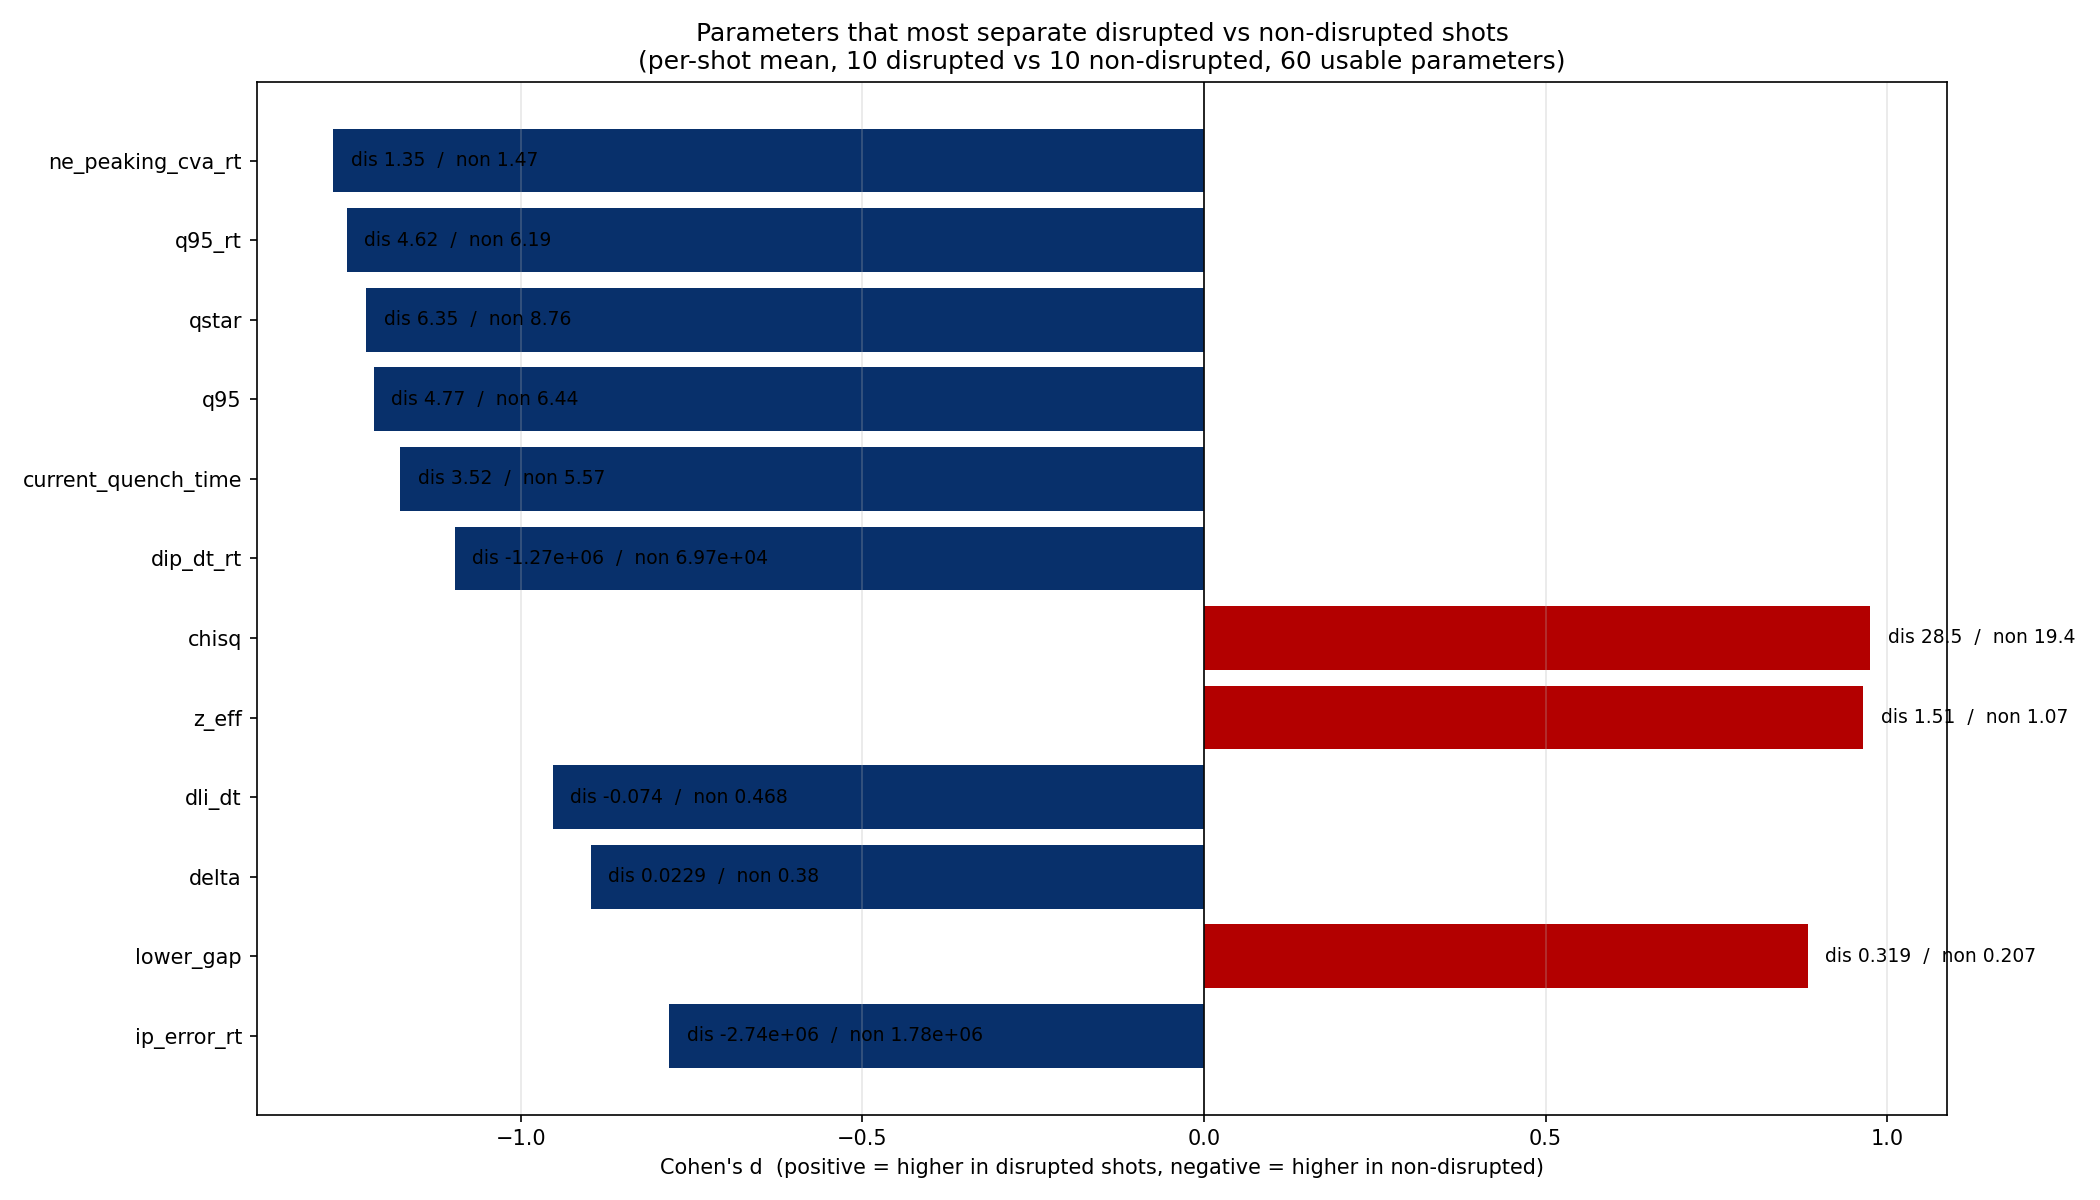

### The parameters that differ most

| Parameter | Cohen's d | Mean (disrupted) | Mean (non-disrupted) | Direction |
|---|---|---|---|---|
| `ne_peaking_cva_rt` | −1.27 | 1.351 | 1.472 | lower in disrupted |
| `q95_rt` | −1.25 | 4.62 | 6.19 | lower in disrupted |
| `qstar` | −1.23 | 6.35 | 8.76 | lower in disrupted |
| `q95` | −1.22 | 4.77 | 6.44 | lower in disrupted |
| `current_quench_time` | −1.18 | 3.52 s | 5.57 s | lower in disrupted |
| `dip_dt_rt` | −1.10 | −1.27 MA/s | +0.07 MA/s | lower in disrupted |
| `chisq` | +0.98 | 28.5 | 19.4 | higher in disrupted |
| `z_eff` | +0.96 | 1.51 | 1.07 | higher in disrupted |
| `dli_dt` | −0.95 | −0.074 s⁻¹ | +0.47 s⁻¹ | lower in disrupted |
| `delta` | −0.90 | 0.023 | 0.380 | lower in disrupted |
| `lower_gap` | +0.88 | 0.319 m | 0.207 m | higher in disrupted |
| `ip_error_rt` | −0.78 | −2.74 MA | +1.78 MA | lower in disrupted |

### What the pattern says

**The strongest separators are all about the safety factor.** `q95`, its real-time twin `q95_rt`, and the cylindrical approximation `qstar` all sit at |d| ≈ 1.2 — the disrupted shots run at markedly **lower q** (q95 ≈ 4.8 vs 6.4). This is the classic disruption-physics signature: low edge safety factor means the plasma is closer to the kink/current limit, and these shots are operating there.

**The disrupted shots are also more MHD-active and less stable.** `chisq` (EFIT fit quality) is higher in disrupted shots (28 vs 19) — the equilibrium reconstruction fits worse, consistent with a perturbed, non-ideal plasma. `dip_dt_rt` is negative in disrupted shots (−1.27 MA/s) vs slightly positive in non-disrupted (+0.07 MA/s) — the disrupted shots are on a decaying current ramp. `dli_dt` (internal inductance evolution) is negative in disrupted shots, and `ip_error_rt` is strongly negative (−2.74 MA) — the measured current is running well below the programmed value, i.e. the plasma is failing to follow the requested current.

**The disrupted shots are hotter and denser per unit current, and less shaped.** `z_eff` is higher (1.51 vs 1.07) and `n_e_rt` is higher (3.4×10¹⁹ vs 2.2×10¹⁹ m⁻³), while `delta` (triangularity) is much lower (0.02 vs 0.38) and `lower_gap` is larger (0.319 m vs 0.207 m). `v_loop` is higher (1.06 vs 0.56 V), consistent with a resistive, less-confined plasma.

**Caveats on the comparison.** `current_quench_time` is disruption-py's *derived* estimate, present for only 3 of the 10 non-disrupted shots (it disagrees with the curated label on 198244, 198643, 199062), so its group means are not directly comparable — I include it only for completeness. `z_eff` is present for only 4 disrupted and 6 non-disrupted shots, `ne_peaking_cva_rt` for 9 disrupted and 7 non-disrupted, and `q95_rt` for 10 disrupted and 9 non-disrupted; all other rows are fully populated (10/10). Effect sizes here are large (|d| > 0.8) but the sample is 10 vs 10, so treat them as descriptive of this slice, not as a generalised DIII-D result.

No image files were read; the chart above is the saved PNG.

In [8]:
%%ask --review
Compare the disrupted shots against the non-disrupted ones in this index.
Which parameters differ most between the two groups? Show the comparison and be
explicit about how many shots are in each group.

---
# 4. Knowing the limits

## How often do DIII-D shots disrupt?

*population · **correctly refused***

The honest answer is that this dataset cannot say. Twenty shots, deliberately
balanced ten and ten, is not a sample of DIII-D.

In [9]:
%%ask --review
What fraction of DIII-D shots disrupt? Use the disruption index to work
it out.

The index's own `disruption_rate()` function is designed to refuse this — let me confirm what it returns and why.



The skill is explicit that this index cannot answer a rate question — `disruption_rate()` exists to return that refusal. Let me call it to confirm the exact response.



Running the script to confirm the refusal and the exact counts.



The index cannot answer this question, and its own `disruption_rate()` function is designed to refuse it. Here is the honest answer.

## The fraction of DIII-D shots that disrupt — not answerable from this index

**The disruption index cannot give you a DIII-D-wide disruption rate.** It holds **20 shots, 10 of them disrupted** — a deliberately balanced, constructed slice, not a random sample of DIII-D. Any fraction computed from it (10/20 = 50%) describes the slice and nothing else; it says nothing about how often DIII-D disrupts as a whole.

I called the index's own `disruption_rate()` function to confirm, and it raises `PopulationClaimUnsupported` rather than return a number:

> This index holds 20 shots, 10 of them disrupted — deliberately balanced, not drawn at random from DIII-D. Any rate computed from it (10/20) describes the slice and says nothing about how often DIII-D disrupts. For an archive-wide rate you need the d3drdb disruptions table over a defined shot population, not this file.

The index's `coverage_note` says the same: *"20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only."*

### What this means

- **The 10/20 split is a design choice, not a measurement.** The slice was built to be balanced so that disrupted and non-disrupted shots can be compared on equal footing — it was never intended to estimate a population rate.
- **A real DIII-D disruption fraction** would need the d3drdb `disruptions` table (the human-curated disruption labels) joined against a defined shot population — e.g. all plasma shots in a campaign or year — and that is outside this index. The d3d-disruption skill explicitly points to `d3d-relational-db` for that.
- **What I can legitimately say from this index** : of the 20 shots it covers, 10 disrupted and 10 did not. That is a statement about the slice, not about DIII-D.

If you want the actual archive-wide disruption fraction, the next step is to query the d3drdb disruptions table over a defined shot population (via the d3d-relational-db skill) — say the word and I can do that. No image files were read; this was a data-availability check.

## What can't this dataset answer?

*scope · **answerable***

In [10]:
%%ask --review
Given everything above, what kinds of questions would this disruption
dataset NOT be able to answer, and what would be needed to answer them?

This is a synthesis question, so I'll draw on everything established across the previous turns. Here is the boundary of what this dataset can and cannot do.

## What this dataset is (the boundary in one line)

A **20-shot, 60-usable-parameter, derived time-series slice** of disruption-py output — deliberately balanced 10 disrupted / 10 not, built from a single NetCDF file, with curated disruption labels and per-parameter annotations. That definition determines every gap below.

## Questions this dataset cannot answer, and what would be needed

### 1. Population and statistical questions — the biggest gap
- What fraction of DIII-D shots disrupt? (established: `disruption_rate()` refuses with `PopulationClaimUnsupported`)
- Disruption rate by campaign, year, current range, or density; whether disruption prevalence is changing over time; how representative any precursor pattern is of the machine as a whole.
- **Why not** : the 10/10 split is a design choice, not a sample. Any rate from it describes the slice only.
- **What's needed** : the d3drdb `disruptions` table (human-curated labels) joined against a defined shot population — e.g. all plasma shots in a campaign or year. That lives in the **d3d-relational-db** skill, which the d3d-disruption skill explicitly points to for exactly this.

### 2. Raw, high-time-resolution waveform questions
- The actual Ip, D-alpha, or n=1 mode *waveforms* at full sampling rate; ELM-resolved or high-frequency MHD analysis; anything needing sub-millisecond detail.
- **Why not** : the index stores parameters *sampled* through each shot, not raw diagnostics. It has no raw waveforms and no ELM times.
- **What's needed** : **d3d-shot-fetcher** (efit01 signals, PTDATA raw digitizer, BES), **d3d-filterscopes** (D-alpha at ~50 kHz), **d3d-elm-index** (ELM burst times) and **d3d-elm-phase-analysis** (ELM-synchronised averaging), **toksearch-mds** for arbitrary MDSplus trees.

### 3. Any shot outside the 20
- What happened in shot 196000, 199000, or any recent campaign shot; whether a specific shot you care about disrupted.
- **Why not** : the index simply has no rows for them. Critically, a shot *absent* from the index is **not** evidence it did not disrupt — it just wasn't run through disruption-py here.
- **What's needed** : run disruption-py on those shots, or query d3drdb for their disruption status (d3d-relational-db).

### 4. Anything built on the three unusable parameters
- Phase classification (`time_domain` — constant 1.0, flat-top test never fires), current-tracking error (`ip_error` — identical to `ip`), programmed-current derivative (`dipprog_dt` — MA/s vs A/s, off by ~5×10⁵).
- **Why not** : these are upstream disruption-py defects (v0.15.0.dev0) that return plausible-but-wrong numbers; the index blocks them.
- **What's needed** : a fixed upstream disruption-py, or use the usable `_rt` twins (`dipprog_dt_rt`, `ip_error_rt`) which do not share the bugs.

### 5. Physics the index does not record
- ELM behaviour (the index has no ELM labels), full kinetic profiles (Te, ne, Ti profiles — it has scalars and a few peaking factors, not profiles), detailed mode structure or radiation profiles, pedestal dynamics.
- **Why not** : 63 scalar/derived parameters cannot reconstruct the full plasma state.
- **What's needed** : the dedicated diagnostics — Thomson/CER/ECE/bolometry via d3d-shot-fetcher and toksearch, ELM labels via d3d-elm-index.

### 6. Causality and mechanism
- *Why* a shot disrupted — which instability triggered it, whether the precursor caused the disruption or merely accompanied it.
- **Why not** : the index records correlations (parameter values vs disruption outcome) on 20 shots; correlation and a tiny sample cannot establish mechanism.
- **What's needed** : controlled experiments, detailed MHD/kinetic diagnostics, and a much larger, representative sample — no single dataset answers this.

## What it *can* answer (for contrast)

Within its 20 shots: which disrupted and when, the pre-disruption plasma state (e.g. the shot-194128 thermal quench, the low-q95 / high-chisq / negative-dip_dt signature separating the two groups), and what each parameter means and its units. That is a **descriptive, per-shot and within-slice** capability — not a population, waveform, or mechanism capability.

## Summary

| Question type | Answerable here? | What's needed |
|---|---|---|
| Which of these 20 shots disrupted, when, and their pre-disruption state | ✅ | — |
| Meaning/units of the 60 usable parameters | ✅ | — |
| DIII-D-wide disruption rate / trends / prevalence | ❌ | d3drdb disruptions table over a defined population (d3d-relational-db) |
| Raw waveforms, ELM times, high-frequency MHD | ❌ | d3d-shot-fetcher, d3d-filterscopes, d3d-elm-index, toksearch-mds |
| Any shot outside the 20 | ❌ | run disruption-py, or d3drdb status lookup |
| Analysis using the 3 unusable parameters | ❌ | fixed disruption-py, or the `_rt` twins |
| ELMs, kinetic profiles, mode structure | ❌ | dedicated diagnostics (Thomson/CER/ECE/bolometry, ELM index) |
| Causality / disruption mechanism | ❌ | controlled experiments + representative sample |

The recurring theme: the index is a **small, curated, derived slice** — excellent for understanding the 20 shots it covers, and deliberately incapable of making claims about DIII-D as a whole. Every gap maps to a specific other skill or dataset that fills it. No image files were read; this is a synthesis of the prior analysis.